# Generate Pilots for Low PAPR

This is a notebook with code to generate pilots for an OFDM signal with a low peak-to-average power ratio (PAPR).

Here, my goal is to generate an all-pilot chnanel OFDM symbol, and repeat it `repetitions` times to create an OFDM packet that is perfectly known and repetitive so that it can be used for channel frequency response estimation.

Because each symbol repeats, there is no need for the cyclic prefix.

In [1]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import scipy.signal as signal
from itertools import chain
from scipy.signal import correlate, correlation_lags, fftconvolve
import matplotlib as mpl

mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
# Set xlabel font size
mpl.rcParams['axes.labelsize'] = 14


In [2]:
#We want the time resolution to be small
Bandwidth = 20e6
deltaT = 1/Bandwidth
print(deltaT)

# We want to know about time delays up to maxDelay in seconds
maxDelay = 10e-6 # sec
freqSamples = int(maxDelay/deltaT)
print(freqSamples)

5e-08
200


## 1. Info about the OFDM transmitted signal


This is where the user can edit the OFDM parameters, including the FFT size, the cyclic prefix (CP) size, the number (and locations) of pilot and guard band subcarriers and the pilot value. **This must match the parameters used in the transmitter**. The 2nd code block below is for displaying to the user which subcarriers are assigned to which purpose.

* The `FFT_size` length vector that represents the OFDM symbol in the frequency domain, one value for each subcarrier. You should set it to be at least 15-20% larger than freqSamples, and a power of 2, so that num_pilots can be >= freqSamples, above.
* `num_pilots` is how many pilots we want. It should be >= freqSamples, above.
*   `pilotValue` is the array of complex values for each pilot subcarrier, as listed in the `pilotCarriers` vector.
*   You don't need to do anything for the guard band subcarriers, because they should be zero.

In [3]:
# Basic OFDM and system parameters
FFT_size = 256                       # Number of FFT points
num_pilots = FFT_size - FFT_size//8

# Subcarrier number assignments used in the TX & RX
pilotCarriers = np.arange(-num_pilots//2, num_pilots//2,1)  # Pilot carriers
pilots = len(pilotCarriers)

# Print the count of each type of subcarrier to the
print('Number of carriers:', FFT_size)
print('Number of pilot carriers:', pilots)


Number of carriers: 256
Number of pilot carriers: 224


This function assembles the all-pilot OFDM symbol in the frequency domain:

*   `data` is a vector with all non-pilots (guard band subcarriers) set to 0.
*   `pilotCarriers` is a list of indices for pilot subcarriers.
*   `pilotValue` is the constant complex value to be put into every pilot subcarrier.

Finally, we use numpy's IFFT command `np.fft.ifft` to calculate the `FFT_size` inverse fast Fourier transform of the `Symbol` vector. We call the output `ofdm_time`.


In [4]:
def calcPAPR(data, pilotCarriers, pilotValue, FFT_size):

  # Compose one symbol's time-domain signal
  data[pilotCarriers] = pilotValue
  ofdm_time = np.fft.ifft(data, n=FFT_size)

  # Compute the average power in ofdm_time
  avg_power = np.mean(np.abs(ofdm_time)**2)
  if avg_power == 0:
    return np.inf()

  # Compute the max power in ofdm_time
  max_power = np.max(np.abs(ofdm_time)**2)
  # Compute PAPR
  papr = max_power/avg_power

  return papr


Now we:

1. randomly generate `sims` number of pilotValue vectors. Each pilot has magnitude 1.0 and uniform phase between 0 and 2$\pi$.
2. Calculate the PAPR of each generated pilotValue vector.
3. Plot the histogram of PAPRs.

Max:  16.47028447134161  Mean:  6.148481308809959  Min:  3.402421905654595


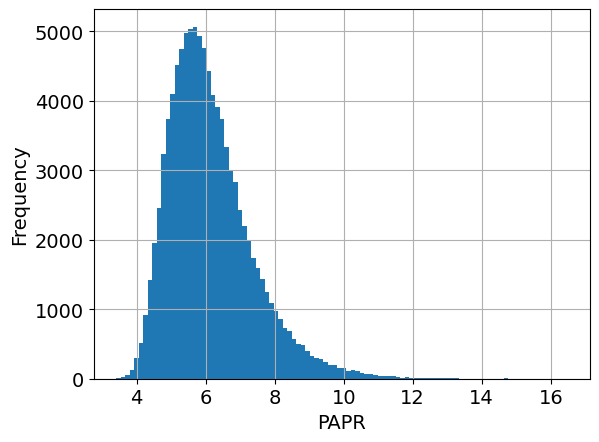

In [5]:
# Basic OFDM and system parameters
FFT_size = 256                       # Number of FFT points
num_pilots = FFT_size - FFT_size//8
sims     = 100000

# Init the data and PAPR vectors
data = np.zeros(FFT_size,dtype=np.complex128)
papr     = np.zeros(sims)

# Generate Pilot IQ value
pilotValue = [np.exp((2j*math.pi)*np.random.rand(pilots)) for i in range(sims)]
papr = [calcPAPR(data, pilotCarriers, pilotValue[i], FFT_size) for i in range(sims)]

# What is the range of values of PAPR?
plt.figure()
plt.hist(papr, bins=100)
plt.xlabel('PAPR')
plt.ylabel('Frequency')
plt.grid(True)
print('Max: ', max(papr), ' Mean: ', np.mean(papr), ' Min: ', min(papr))

Can we see anything in the phases of the best pilotValue vector, vs. the worst?

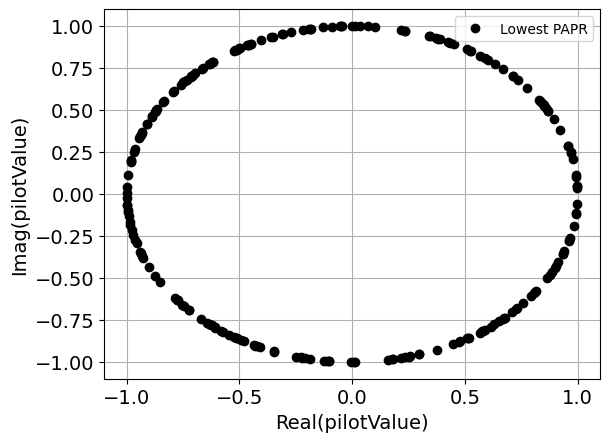

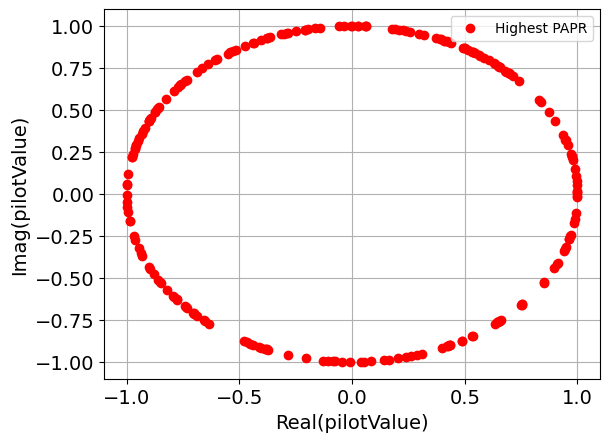

In [21]:
bestInd = np.argmin(papr)
worstInd = np.argmax(papr)
plt.figure()
plt.plot(np.real(pilotValue[bestInd]), np.imag(pilotValue[bestInd]), 'k.', markersize=12, label="Lowest PAPR")
plt.xlabel('Real(pilotValue)')
plt.ylabel('Imag(pilotValue)')
plt.legend()
plt.grid(True)
plt.figure()
plt.plot(np.real(pilotValue[worstInd]), np.imag(pilotValue[worstInd]), 'r.', markersize=12, label="Highest PAPR")
plt.xlabel('Real(pilotValue)')
plt.ylabel('Imag(pilotValue)')
plt.legend()
plt.grid(True)

plt.show()

In [7]:
# Generate a linear range from 0 to 2$\pi$ for the pilot angles, and calc the PAPR
uniformPilots = np.exp((2j*math.pi)*np.arange(pilots)/pilots)
paprUniform = calcPAPR(data, pilotCarriers, uniformPilots, FFT_size)
print(paprUniform)

212.71984752223563


In [8]:
# shuffle the linear list of angles and generate pilotValue that way.
angles = np.arange(0, 1, 1.0/pilots)
np.random.shuffle(angles)
uniformReorderedPilots = np.exp((2j*math.pi)*angles)
paprUniform = calcPAPR(data, pilotCarriers, uniformReorderedPilots, FFT_size)
print(paprUniform)

6.382472947756839


In [9]:
uniformPilots = np.ones(pilots)
paprUniform = calcPAPR(data, pilotCarriers, uniformPilots, FFT_size)
print(paprUniform)

224.0


Plot the best (lowest PAPR) pilotValue vector in the time domain.

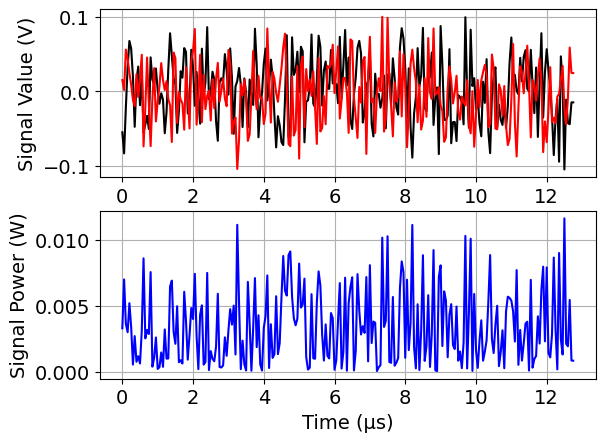

In [10]:
# Assume sample rate = `Bandwidth`
T_sample = 1/Bandwidth

# Compose one symbol's time-domain signal
data[pilotCarriers] = pilotValue[bestInd]
ofdm_time = np.fft.ifft(data, n=FFT_size)
t = np.arange(0, FFT_size)*(T_sample / 1e-6)

# Plot
plt.figure()
plt.subplot(2,1,1)
plt.plot(t, np.real(ofdm_time),'k-', t, np.imag(ofdm_time),'r-')
plt.ylabel('Signal Value (V)')
plt.grid(True)
plt.subplot(2,1,2)
plt.plot(t, np.abs(ofdm_time)**2,'b-')
plt.xlabel(u'Time (μs)')
plt.ylabel('Signal Power (W)')
plt.grid(True)


Plot the angles of the best (lowest PAPR) pilotValue vector in the freq domain.

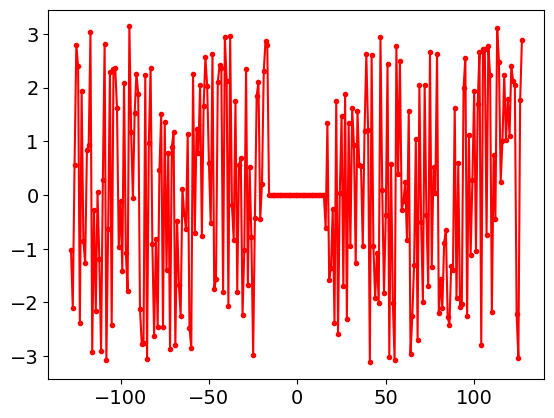

In [11]:
plt.figure()
plt.plot(range(-FFT_size//2, FFT_size//2), np.angle(data),'r.-')

## Save the results to file

Generate the IQ values in the transmitted packet, and save it to a binary IQ file for later transmission.

In [18]:
repetitions = 1000
# How many samples is this, and what duration?
packet_samples = repetitions * FFT_size
packet_duration = packet_samples * T_sample
print('packet_samples: ', packet_samples)
print('packet_duration: ', packet_duration)


# Normalize the `ofdm_time` vector so that the max real or imaginary part is 1
max_real = np.max(np.abs(np.real(ofdm_time)))
max_imag = np.max(np.abs(np.imag(ofdm_time)))
max_either = max(max_real, max_imag)
if max_either > 0:
  norm_ofdm_time = ofdm_time / max_either

# Concatenate
repeatingSignal = np.repeat(norm_ofdm_time, repetitions, axis=0)


packet_samples:  256000
packet_duration:  0.012799999999999999


In [17]:
# PURPOSE: Open filename and write array to it as binary
# INPUT: data to write as binary, filename to write to
# OUTPUT: file with complex binary data
def write_complex_binary(data, filename):
    # Open filename and write array to it as binary, format is interleaved float IQ
    re = np.real(data)
    im = np.imag(data)
    binary = np.zeros(len(data)*2, dtype=np.float32)
    binary[::2] = re
    binary[1::2] = im
    binary.tofile(filename)

In [20]:
IQ_filename = 'channel-sounding-OFDM-packet' ### TODO ###

# Add the .iq extension and write the file.
IQ_filename_ext = IQ_filename + '.iq'
write_complex_binary(repeatingSignal, IQ_filename_ext)
print('IQ file generated')

IQ file generated


In [23]:
# Write one repetition of the symbol `norm_ofdm_time` to a separate file.
# This is the `preamble` that the receiver will look for to know what sample 0 is.
packet_preamble_filename = 'channel-sounding-one-symbol'

packet_preamble_filename_ext = packet_preamble_filename + '.iq'
write_complex_binary(norm_ofdm_time, packet_preamble_filename_ext)
print('Preamble (one symbol) file generated')

Preamble (one symbol) file generated
